In [23]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Text processing
import re
import string

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

# Files imported
# archive.zip

Libraries imported successfully!


In [24]:
# Step 2: Extract and Load the IMDb Movie Review Dataset

import zipfile
import os

# Extract the ZIP file
with zipfile.ZipFile("/content/archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/imdb_data")

# See what files were extracted
print("Files:", os.listdir("/content/imdb_data"))

# Load the dataset
df = pd.read_csv("/content/imdb_data/IMDB Dataset.csv")

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Files: ['IMDB Dataset.csv']

Dataset loaded successfully!
Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [25]:
# Step 3: Inspect the Dataset

print("Dataset Information:")
print("-" * 40)
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nSentiment Percentages:")
print(df["sentiment"].value_counts(normalize=True) * 100)

Dataset Information:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing Values:
review       0
sentiment    0
dtype: int64

Duplicate Rows:
418

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sentiment Percentages:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [26]:
# Step 4: Remove Duplicate Reviews

print("Rows before removing duplicates:", len(df))

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", len(df))
print("Duplicates remaining:", df.duplicated().sum())

# Check sentiment distribution after removing duplicates
print("\nSentiment distribution after cleaning:")
print(df["sentiment"].value_counts())

Rows before removing duplicates: 50000
Rows after removing duplicates: 49582
Duplicates remaining: 0

Sentiment distribution after cleaning:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [27]:
# Step 5: Clean and Preprocess Review Text

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply cleaning function
df["clean_review"] = df["review"].apply(clean_text)

# Compare original and cleaned review
print("ORIGINAL REVIEW:")
print(df["review"].iloc[0][:500])

print("\nCLEANED REVIEW:")
print(df["clean_review"].iloc[0][:500])

ORIGINAL REVIEW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

CLEANED REVIEW:
one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called o

Review Length Statistics:
count    49582.000000
mean       228.171272
std        169.106362
min          4.000000
25%        125.000000
50%        171.000000
75%        277.000000
max       2459.000000
Name: word_count, dtype: float64

Average Word Count by Sentiment:
sentiment
negative    226.299498
positive    230.029055
Name: word_count, dtype: float64


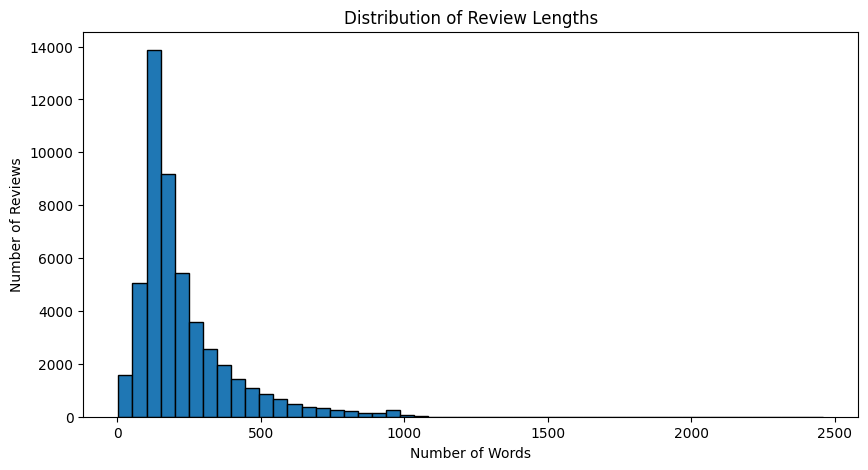

In [28]:
# Step 6: Analyze Review Lengths

# Count the number of words in each cleaned review
df["word_count"] = df["clean_review"].apply(lambda x: len(x.split()))

print("Review Length Statistics:")
print(df["word_count"].describe())

# Compare average review length by sentiment
print("\nAverage Word Count by Sentiment:")
print(df.groupby("sentiment")["word_count"].mean())

# Plot review length distribution
plt.figure(figsize=(10, 5))
plt.hist(df["word_count"], bins=50, edgecolor="black")
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()


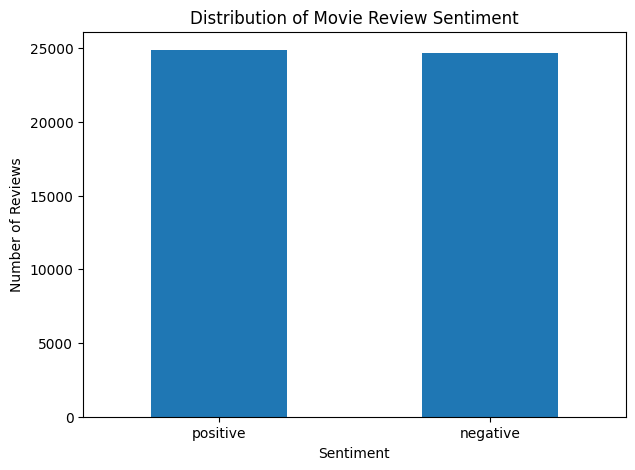

Sentiment Counts:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Sentiment Percentages:
sentiment
positive    50.19
negative    49.81
Name: count, dtype: float64


In [29]:
# Step 7: Visualize Sentiment Distribution

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Distribution of Movie Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

# Display counts and percentages
print("Sentiment Counts:")
print(sentiment_counts)

print("\nSentiment Percentages:")
print((sentiment_counts / len(df) * 100).round(2))

In [30]:
# Step 8: Encode Sentiment Labels

# Convert sentiment labels to numbers
df["sentiment_label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

# Check the results
print("Sentiment Label Mapping:")
print(df[["sentiment", "sentiment_label"]].head(10))

print("\nLabel Counts:")
print(df["sentiment_label"].value_counts())

print("\nMissing Labels:")
print(df["sentiment_label"].isnull().sum())

Sentiment Label Mapping:
  sentiment  sentiment_label
0  positive                1
1  positive                1
2  positive                1
3  negative                0
4  positive                1
5  positive                1
6  positive                1
7  negative                0
8  negative                0
9  positive                1

Label Counts:
sentiment_label
1    24884
0    24698
Name: count, dtype: int64

Missing Labels:
0


In [31]:
# Step 9: Split Data into Training and Testing Sets

# Features and target
X = df["clean_review"]
y = df["sentiment_label"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training reviews: 39665
Testing reviews: 9917

Training label distribution:
sentiment_label
1    0.5019
0    0.4981
Name: proportion, dtype: float64

Testing label distribution:
sentiment_label
1    0.5019
0    0.4981
Name: proportion, dtype: float64


In [ ]:
# Step 10: Convert Review Text into TF-IDF Features

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Learn vocabulary from training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform testing data using the SAME vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF vectorization complete!")

print("\nTraining matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

print("\nNumber of TF-IDF features:", len(tfidf.get_feature_names_out()))

print("\nSample features:")
print(tfidf.get_feature_names_out()[:20])

In [ ]:
# Step 11: Train Logistic Regression Model

# Create the model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg.fit(X_train_tfidf, y_train)

# Make predictions on unseen test data
y_pred_log = log_reg.predict(X_test_tfidf)

print("Logistic Regression model trained successfully!")

# Calculate evaluation metrics
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("\nLogistic Regression Performance:")
print(f"Accuracy:  {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall:    {log_recall:.4f}")
print(f"F1 Score:  {log_f1:.4f}")

In [ ]:
# Step 12: Logistic Regression Classification Report and Confusion Matrix

print("Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_log,
        target_names=["Negative", "Positive"]
    )
)

# Create confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

print("Confusion Matrix:")
print(cm_log)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# Step 13: Train Multinomial Naive Bayes Model

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes model trained successfully!")

# Calculate evaluation metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("\nMultinomial Naive Bayes Performance:")
print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1 Score:  {nb_f1:.4f}")

In [ ]:
# Step 14: Compare Model Performance

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        log_accuracy,
        nb_accuracy
    ],
    "Precision": [
        log_precision,
        nb_precision
    ],
    "Recall": [
        log_recall,
        nb_recall
    ],
    "F1 Score": [
        log_f1,
        nb_f1
    ]
})

# Round results
model_comparison.iloc[:, 1:] = model_comparison.iloc[:, 1:].round(4)

print("Model Performance Comparison:")
display(model_comparison)

# Plot model comparison
model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment Classification Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Step 15: Identify Important Sentiment Features

# Get feature names and Logistic Regression coefficients
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = log_reg.coef_[0]

# Get indices of strongest positive and negative features
top_positive_indices = np.argsort(coefficients)[-20:][::-1]
top_negative_indices = np.argsort(coefficients)[:20]

# Create DataFrames
top_positive = pd.DataFrame({
    "Feature": feature_names[top_positive_indices],
    "Coefficient": coefficients[top_positive_indices]
})

top_negative = pd.DataFrame({
    "Feature": feature_names[top_negative_indices],
    "Coefficient": coefficients[top_negative_indices]
})

print("Top Features Associated with Positive Sentiment:")
display(top_positive)

print("\nTop Features Associated with Negative Sentiment:")
display(top_negative)

In [ ]:
# Step 17: Test the Model on New Movie Reviews

new_reviews = [
    "This movie was absolutely amazing. The acting was excellent and I loved the story.",
    "This was one of the worst movies I have ever seen. It was boring and a complete waste of time.",
    "The movie was entertaining and the characters were great.",
    "The plot was terrible and I would not recommend this movie."
]

# Clean the new reviews using the same cleaning function
cleaned_new_reviews = [clean_text(review) for review in new_reviews]

# Convert reviews to TF-IDF features
new_reviews_tfidf = tfidf.transform(cleaned_new_reviews)

# Predict sentiment using Logistic Regression
predictions = log_reg.predict(new_reviews_tfidf)

# Get prediction probabilities
probabilities = log_reg.predict_proba(new_reviews_tfidf)

# Display results
results = pd.DataFrame({
    "Review": new_reviews,
    "Predicted Sentiment": [
        "Positive" if prediction == 1 else "Negative"
        for prediction in predictions
    ],
    "Confidence": [
        probabilities[i][prediction]
        for i, prediction in enumerate(predictions)
    ]
})

results["Confidence"] = (results["Confidence"] * 100).round(2).astype(str) + "%"

display(results)

In [ ]:
# Step 18: Analyze Misclassified Reviews

# Create DataFrame with test results
error_analysis = pd.DataFrame({
    "Review": X_test,
    "Actual": y_test,
    "Predicted": y_pred_log
})

# Convert numeric labels back to sentiment names
error_analysis["Actual Sentiment"] = error_analysis["Actual"].map({
    0: "Negative",
    1: "Positive"
})

error_analysis["Predicted Sentiment"] = error_analysis["Predicted"].map({
    0: "Negative",
    1: "Positive"
})

# Keep only incorrect predictions
misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print("Total test reviews:", len(error_analysis))
print("Misclassified reviews:", len(misclassified))

print(
    "Misclassification rate:",
    f"{len(misclassified) / len(error_analysis) * 100:.2f}%"
)

print("\nSample Misclassified Reviews:")

display(
    misclassified[
        ["Review", "Actual Sentiment", "Predicted Sentiment"]
    ].head(10)
)

In [ ]:
# Step 19: Analyze False Positives and False Negatives

# False Positives:
# Actual = Negative (0), Predicted = Positive (1)
false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]

# False Negatives:
# Actual = Positive (1), Predicted = Negative (0)
false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

print("Error Analysis:")
print("-" * 40)

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))
print("Total Errors:", len(false_positives) + len(false_negatives))

print("\nPercentage of Errors:")
print(
    "False Positives:",
    f"{len(false_positives) / len(misclassified) * 100:.2f}%"
)

print(
    "False Negatives:",
    f"{len(false_negatives) / len(misclassified) * 100:.2f}%"
)

In [ ]:
# Step 20: Create Final Model Summary

print("=" * 60)
print("IMDb MOVIE REVIEW SENTIMENT ANALYSIS")
print("=" * 60)

print("\nDATASET")
print(f"Cleaned Reviews: {len(df):,}")
print(f"Training Reviews: {len(X_train):,}")
print(f"Testing Reviews: {len(X_test):,}")
print("TF-IDF Features: 10,000")

print("\nLOGISTIC REGRESSION PERFORMANCE")
print(f"Accuracy:  {log_accuracy:.2%}")
print(f"Precision: {log_precision:.2%}")
print(f"Recall:    {log_recall:.2%}")
print(f"F1 Score:  {log_f1:.2%}")

print("\nMULTINOMIAL NAIVE BAYES PERFORMANCE")
print(f"Accuracy:  {nb_accuracy:.2%}")
print(f"Precision: {nb_precision:.2%}")
print(f"Recall:    {nb_recall:.2%}")
print(f"F1 Score:  {nb_f1:.2%}")

print("\nERROR ANALYSIS")
print(f"Misclassified Reviews: {len(misclassified):,}")
print(f"Misclassification Rate: {len(misclassified)/len(X_test):.2%}")
print(f"False Positives: {len(false_positives):,}")
print(f"False Negatives: {len(false_negatives):,}")

print("\nKEY FINDING")
print(
    "Logistic Regression outperformed Multinomial Naive Bayes "
    "on the held-out test set across accuracy, precision, recall, "
    "and F1 score."
)

print("=" * 60)

In [ ]:
# Step 21: Create Final Model Performance Dashboard

models = ["Logistic Regression", "Multinomial Naive Bayes"]

accuracy = [log_accuracy, nb_accuracy]
precision = [log_precision, nb_precision]
recall = [log_recall, nb_recall]
f1 = [log_f1, nb_f1]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(11, 6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1 Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("IMDb Sentiment Classification Model Performance")
plt.ylim(0.80, 0.92)
plt.legend()

# Add score labels
for i in range(len(models)):
    values = [accuracy[i], precision[i], recall[i], f1[i]]
    positions = [
        x[i] - 1.5*width,
        x[i] - 0.5*width,
        x[i] + 0.5*width,
        x[i] + 1.5*width
    ]

    for position, value in zip(positions, values):
        plt.text(
            position,
            value + 0.002,
            f"{value:.1%}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [ ]:
## Project Conclusion

# This project developed a machine learning sentiment classification pipeline to predict whether IMDb movie reviews were positive or negative.

# The dataset contained 50,000 movie reviews. After removing 418 duplicate records, 49,582 reviews remained for analysis. Text reviews were cleaned and transformed into 10,000 TF-IDF features before training and evaluating two classification models: Logistic Regression and Multinomial Naive Bayes.

### Key Results

# - Logistic Regression achieved 89.18% test accuracy and an 89.37% F1 score.
# - Multinomial Naive Bayes achieved 86.20% test accuracy and an 86.46% F1 score.
# - Logistic Regression performed better across accuracy, precision, recall, and F1 score on the held-out test set.
# - Logistic Regression correctly identified 4,335 negative and 4,509 positive reviews.
# - The model misclassified 1,073 of 9,917 test reviews, resulting in a 10.82% error rate.
# - Of the model's errors, 605 were false positives and 468 were false negatives.
# - Testing on new example reviews demonstrated how the trained pipeline can classify previously unseen text.

### Skills Demonstrated

# Python, Pandas, NumPy, Matplotlib, Scikit-learn, Natural Language Processing (NLP), text preprocessing, TF-IDF vectorization, Logistic Regression, Naive Bayes, model evaluation, confusion matrices, feature interpretation, and error analysis.

### Final Takeaway

# The project demonstrates an end-to-end NLP workflow, from raw text preprocessing and exploratory analysis through feature engineering, model training, model comparison, interpretation, and error analysis. Logistic Regression provided the stronger performance of the two evaluated models on this dataset.